# Laboratorium 5: Segmentacja polipów — Architektura typu U-Net(Kvasir-SEG)

W tym ćwiczeniu chcemy nauczyć się budowania i trenowania modeli **segmentacji semantycznej** z wykorzystaniem architektury **U-Net** oraz frameworka **PyTorch Lightning** na zbiorze danych medycznych **Kvasir-SEG** (segmentacja polipów jelitowych w obrazach endoskopowych).

**Główne zagadnienia:**
- Implementacja `LightningDataModule`: podział train/val/test, augmentacje spójne dla obrazu i maski.
- Budowa architektury **U-Net 2D** z enkoderem i dekoderem oraz skip connections.
- Funkcje straty dla segmentacji: **BCEWithLogitsLoss** i **Dice Loss**.
- Metryki: **Dice Score** i **IoU** (Intersection over Union) z biblioteki torchmetrics.
- Wykorzystanie **Transfer Learning** ResNet jako encoder w U-Net.

**Dataset:** 
Użyjemy **Kvasir-SEG** – zbioru zawierającego obrazy endoskopowe jelita grubego wraz z maskami segmentacji polipów. Dataset ten został stworzony do oceny algorytmów segmentacji w endoskopii i zawiera około 1000 par obraz-maska. Dane zostaną **automatycznie pobrane** w notebooku. Skalujemy je również do rozdzielczości 224x224 aby ograniczyć czas potrzebny na uczenie sieci.

## 0) Instalacja i importy

Jeśli chcemy powtarzalnych wyników możemy ustawić stały SEED.

In [1]:
# !pip -q install pytorch-lightning torchmetrics scikit-image opencv-python pillow --extra-index-url https://download.pytorch.org/whl/cpu

import os, zipfile, urllib.request, random, glob, math
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import ssl
from pathlib import Path

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import pytorch_lightning as pl
from pytorch_lightning import LightningModule, LightningDataModule, Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score

import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torchvision
import torchvision.transforms as T


# SEED = 42
SEED = None
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

if SEED is not None:
    set_seed()
    
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device, '| Lightning:', pl.__version__)

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | Lightning: 2.5.5


## 1) Pobranie i przygotowanie Kvasir-SEG

**Kvasir-SEG** to zbiór danych zawierający obrazy endoskopowe jelita grubego wraz z maskami segmentacji polipów. Poniższy fragment automatycznie pobiera zbiór i sprawdza liczbę pobranych plików. 

Należy zwrócić uwagę, że dla zadania segmentacji zarówno obrazy wejściowe jak i groundtruth są obrazami. W przypadku segmentacji binarnej (tło-obiekt) maska ma wartości binarne. Wymusza to delikatnie inne podejście do zarządzania i przetwarzania wstępnego takich danych.

In [2]:
DATA_ROOT = Path('sem2/PIAOM/lab5/data/data_kvasir')
DATA_ROOT.mkdir(parents=True, exist_ok=True)

ZIP_URL = 'https://datasets.simula.no/downloads/kvasir-seg.zip'
ZIP_PATH = DATA_ROOT / 'kvasir.zip'
EXTRACT_DIR = DATA_ROOT / 'Kvasir-SEG'

if not EXTRACT_DIR.exists():
    print('Pobieranie Kvasir-SEG (~150 MB)…')
    ssl._create_default_https_context = ssl._create_unverified_context
    urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    print('Rozpakowywanie…')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(DATA_ROOT)
    print('Gotowe:', EXTRACT_DIR)
else:
    print('Dane już dostępne:', EXTRACT_DIR)

IMG_DIR = EXTRACT_DIR / 'images'
MSK_DIR = EXTRACT_DIR / 'masks'
imgs = sorted(glob.glob(str(IMG_DIR / '*.jpg')))
msks = sorted(glob.glob(str(MSK_DIR / '*.jpg')))
print('Liczba obrazów/masek:', len(imgs), len(msks))
assert len(imgs) == len(msks) and len(imgs) > 0, 'Brak danych lub brak par obraz–maska.'

Dane już dostępne: sem2/PIAOM/lab5/data/data_kvasir/Kvasir-SEG
Liczba obrazów/masek: 1000 1000


## Zadanie 1 – Dataset i DataModule dla segmentacji

W tym zadaniu zaimplementujesz własny Dataset oraz DataModule dla danych segmentacyjnych. Kluczową różnicą w porównaniu do klasyfikacji jest to, że augmentacje zmieniające pozycję obiektów (wszystkie przekształcenia geometryczne) muszą być stosowane zarówno do obrazu jak i maski – np. jeśli obracamy obraz o 10 stopni, to maskę również musimy obrócić o dokładnie ten sam kąt.

**Dataset dla segmentacji:**
1. Zaimplementuj klasę `KvasirDataset`, która dziedziczy po `Dataset`.
2. W metodzie `__init__` zapamiętaj ścieżki do obrazów (`img_paths`) i masek (`msk_paths`), oraz opcjonalny obiekt transform.
3. W metodzie `__len__` zwróć liczbę obrazów.
4. W metodzie `__getitem__`:
   - Wybierz odpowiednie ścieżki z zapamiętanych list podczas inicjalizacji.
   - Wczytaj obraz i maskę używając funkcji pomocniczej `load_pair`.
   - Jeśli `self.transform` istnieje, zastosuj go do obu (obraz, maska).
   - Zwróć parę (obraz, maska).

**Transform dla segmentacji:**
1. Zaimplementuj klasę `SegmentationTransform`, która będzie stosować te same transformacje do obrazu i maski. W przypadku segmentacji musimy sami ją zaimplementować, aby móć stosować spójną segmentację dla obu obrazów.
2. W metodzie `__init__`:
   - Zapamiętaj `size` (docelowy rozmiar obrazu).
   - Zapamiętaj `augment` (flaga czy stosować augmentacje, domyślnie False).
   - Stwórz obiekt do konwersji PIL do tensor: `transforms.ToTensor()`.
   - Stwórz **dwa** obiekty do resize: `transforms.Resize(size, ...)`. Pierwszy z interpolacją BILINEAR dla obrazu, a drugi z interpolacją NEAREST dla maski. Jest to ważne, gdyż maska jest binarna i nie chcemy rozmywać jej krawędzi.
   - Stwórz obiekt normalizacji: `transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])` – przesunie wartości z [0,1] do [-1,1].
3. W metodzie `__call__(self, img, mask)`:
   - Wykonaj resize dla obrazu i maski (na obrazach PIL).
   - Skonwertuj oba do tensorów (wartości [0, 1]).
   - Zbinaryzuj maskę: `mask = (mask > 0).float()` – chcemy, żeby maska zawiera tylko 0 i 1, ale miała typ zmiennoprzecinkowy.
   - Jeśli `self.augment == True`:
     - Z prawdopodobieństwem 50% wykonaj horizontal flip (dla obu).
     - Z prawdopodobieństwem 50% wykonaj losową rotację o kąt z przedziału [-10, 10] stopni. Zrób to samo dla obu obrazów, ale z różną interpolacją. Wykorzystaj `transforms.functional.rotate` i podaj argument `interpolation`.
   - Znormalizuj obraz (nie maskę) do [-1, 1].
   - Zwróć `(img.float(), mask.float())`.

**DataModule:**
1. Zaimplementuj klasę `KvasirDataModule`, która dziedziczy po `LightningDataModule`.
2. W metodzie `__init__`:
   - Zapamiętaj listy obrazów i masek.
   - Zapamiętaj `batch`, `nw` (num_workers), `train_split`, `val_split`, `img_size`.
   - Stwórz dwa obiekty transformacji: `self.train_transform` (z augment=True) i `self.val_test_transform` (z augment=False) jako obiekty zaimplementowanej wcześniej klasy.
3. W metodzie `setup(self, stage=None)`:
   - Wylosuj indeksy i podziel dane na train/val/test zgodnie z `train_split` i `val_split`. W tym celu stwórz listę indeksów od 0 do liczby próbek, a następnie wymieszaj je za pomocą `np.random.shuffle`. Podziel wynikowy wektor na 3 częsci zgodnie za przekazanym podziałem na część treningową, walidacyjną i testową. Następnie podziel również odpowiednio ścieżki do plików zgodnie z przygotowanymi listami indeksów.
   - Stwórz i zapamiętaj trzy datasety (treningowy, walidacyjny i testowy) z odpowiednimi transformacjami i zawierające próbki zgodnie w wcześniejszym losowaniem.
   - Wyświetl rozmiary zbiorów.
4. Zaimplementuj metody `train_dataloader()`, `val_dataloader()`, `test_dataloader()`:
   - Zwróć DataLoader z odpowiednim datastem.
   - Ustaw `shuffle=True` tylko dla train.
   - Ustaw `pin_memory=True` jeśli CUDA dostępne.

**Poza klasami:**
1. Stwórz instancję `KvasirDataModule` z listami `imgs` i `msks` (były stworzone we wcześniejszej komórce), rozmiarem batcha i liczbą workerów. Wartości te trzeba dobrać na podstawie specyfikacji maszyny na której uruchamiany będzie trening.
2. Wywołaj `dm.setup()`.
3. Pobierz jeden batch z train loadera (`next(iter(dm.train_dataloader()))`) i wyświetl kształty. Powinny pojawić się kształty typu `(16, 3, 384, 384)` dla obrazów i `(16, 1, 384, 384)` dla masek.

In [3]:
from torchvision.transforms import functional as tvF


class KvasirDataset(Dataset):
    def __init__(self, img_paths: Path, mask_paths: Path, transform: transforms):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)
    
    def load_pairs(self, img_path, mask_path):
        img = Image.open(img_path)
        mask = Image.open(mask_path)
        mask = mask.convert("L")

        if self.transform:
            img, mask = self.transform(img, mask)

        return img, mask
    
    def __getitem__(self, index):
        img_path = self.img_paths[index]
        mask_path = self.mask_paths[index]

        img, mask = self.load_pairs(img_path, mask_path)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
    
class SegmentationTransform:
    def __init__(self, size: int, augment: bool = False):
        self.size = size
        self.augment = augment

        self.Img_resize = transforms.Resize((size, size), transforms.InterpolationMode.BILINEAR)
        self.Mask_resize = transforms.Resize((size, size), transforms.InterpolationMode.NEAREST)

        self.norm = transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                         std=[0.5, 0.5, 0.5])

    def __call__(self, img: Image.Image, mask: Image.Image):
        if self.augment:
            if random.random() < 0.5:
                img = tvF.hflip(img)
                mask = tvF.hflip(mask)
            if random.random() < 0.5:
                img = tvF.vflip(img)
                mask = tvF.vflip(mask)
            if random.random() < 0.5:
                angle = random.uniform(-30, 30)
                img = tvF.rotate(img, angle)
                mask = tvF.rotate(mask, angle)

        img = self.Img_resize(img)
        mask = self.Mask_resize(mask)

        img = transforms.ToTensor()(img)
        mask = torch.as_tensor(tvF.to_tensor(mask), dtype=torch.float32)

        img = self.norm(img)

        mask = (mask > 0.5).float()  # 0 lub 1

        return img, mask

class KvasirDataModule(LightningDataModule):
    def __init__(self, imgs_paths: list, mask_paths: list, batch: int, nw: int = 5, train_split: float = 0.7, test_split: float = 0.15, val_split: float = 0.15):
        super().__init__()
        self.imgs_paths = imgs_paths
        self.mask_paths = mask_paths

        self.batch = batch
        self.nw = nw

        self.train_split = train_split
        self.test_split = test_split
        self.val_split = val_split

        self.train_transform = SegmentationTransform(128, True)
        self.val_test_transform = SegmentationTransform(128, False)

        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None


    def setup(self, stage=None):
        num_sapmles = len(self.imgs_paths)
        idx = np.arange(num_sapmles)
        np.random.shuffle(idx)

        n_train = int(self.train_split*num_sapmles)
        n_test = int(self.test_split*num_sapmles)
        n_val = int(self.val_split*num_sapmles)

        train_idx = idx[:n_train]
        val_idx = idx[n_train:n_train + n_val]
        test_idx = idx[n_train + n_val:]

        train_imgs = [self.imgs_paths[i] for i in train_idx]
        train_masks = [self.mask_paths[i] for i in train_idx]

        test_imgs = [self.imgs_paths[i] for i in test_idx]
        test_masks = [self.mask_paths[i] for i in test_idx]

        val_imgs = [self.imgs_paths[i] for i in val_idx]
        val_masks = [self.mask_paths[i] for i in val_idx]

        self.train_dataset = KvasirDataset(train_imgs, train_masks, transform=self.train_transform)
        self.val_dataset = KvasirDataset(val_imgs, val_masks, transform=self.val_test_transform)
        self.test_dataset = KvasirDataset(test_imgs, test_masks, transform=self.val_test_transform)

        print("gut gut")

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch, shuffle=True,
                          num_workers=self.nw, pin_memory=torch.cuda.is_available())

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch, shuffle=False,
                          num_workers=self.nw, pin_memory=torch.cuda.is_available())

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch, shuffle=False,
                          num_workers=self.nw, pin_memory=torch.cuda.is_available())

dm = KvasirDataModule(imgs, msks, batch=16)
dm.setup() 

next(iter(dm.train_dataloader()))

gut gut


/tmp/ipykernel_190116/388602963.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
/tmp/ipykernel_190116/388602963.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
/tmp/ipykernel_190116/388602963.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
/tmp/ipykernel_190116/388602

[tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]],
 
          [[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]],
 
          [[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
         

/tmp/ipykernel_190116/388602963.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
/tmp/ipykernel_190116/388602963.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
/tmp/ipykernel_190116/388602963.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)
/tmp/ipykernel_190116/388602

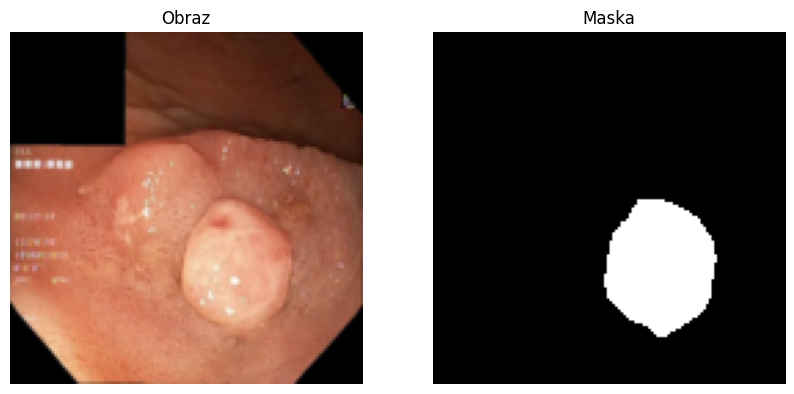

In [4]:
import matplotlib.pyplot as plt

# Pobieramy batch
imgs, masks = next(iter(dm.train_dataloader()))

# Wybieramy pierwszy element
img = imgs[0]    # [3, H, W]
mask = masks[0]  # [1, H, W] lub [H, W]

# Transpozycja obrazu do [H, W, C] dla matplotlib
img_np = img.permute(1, 2, 0).cpu().numpy()
img_np = (img_np * 0.5 + 0.5).clip(0, 1)  # denormalizacja

# Maska do [H, W]
mask_np = mask.squeeze().cpu().numpy()  # usuwa kanał jeśli jest [1, H, W]

# Wyświetlenie
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Obraz")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Maska")
plt.imshow(mask_np, cmap="gray")
plt.axis("off")

plt.show()


In [5]:
mask_np.shape

(128, 128)

## Zadanie 2 – Implementacja U-Net: architektura enkodera i dekodera

W tym zadaniu zaimplementujesz architekturę **U-Net** – jedną z najpopularniejszych sieci do segmentacji medycznej. U-Net składa się z:
- **Enkodera** (downsampling path): ekstraktuje cechy wysokiego poziomu, zmniejszając rozdzielczość.
- **Dekodera** (upsampling path): odbudowuje rozdzielczość, tworząc maskę segmentacji.
- **Skip connections**: połączenia z enkodera do dekodera na tym samym poziomie rozdzielczości – pozwalają zachować szczegóły przestrzenne.

![U-Net architecture diagram](https://iq.opengenus.org/content/images/2021/12/1_ovEGmOI3bcCeauu8jEBzsg.png)

**Blok DoubleConv:**
1. Zaimplementuj klasę `DoubleConv`, która dziedziczy po `nn.Module`.
2. Przyjmuje parametry: `in_ch` (kanały wejściowe), `out_ch` (kanały wyjściowe), `dropout` (prawdopodobieństwo dropout, domyślnie 0.0).
Dropout to technika regularyzacji, która losowo "wyłącza" pewien procent neuronów podczas treningu. Zmusza to sieć do uczenia się bardziej uniwersalnych i odpornych reprezentacji, ponieważ nie może polegać na pojedynczych neuronach/kanałach. Będziemy wykorzystywać `Dropout2d`, który usuwa całe kanały w warstwach konwolucyjnych. Warstwy te pozwalają ograniczyć zjawisko przeuczenia (overfitting).
3. Zbuduj sekwencję warstw:
   - `Conv2d(in_ch, out_ch, kernel_size=3, padding=1)` – konwolucja bez zmiany rozmiaru.
   - `BatchNorm2d(out_ch)` – normalizacja batch.
   - `ReLU(inplace=True)` – aktywacja.
   - Opcjonalnie: `Dropout2d(p=dropout)` jeśli dropout > 0.
   - Powtórz: `Conv2d(out_ch, out_ch, 3, padding=1)`, `BatchNorm2d`, `ReLU`. Ewentualnie może tutaj również nastąpić zmiana liczby kanałów wyjściowych. Wtedy na wejściu podczas inicjalizacji musimy przekazać dodatkowy parametr.
   - Opcjonalnie: ponownie `Dropout2d(p=dropout)` jeśli dropout > 0.
4. W metodzie `forward(x)` przepuść dane przez zbudowaną sekwencję.

**Model UNetSmall:**
1. Zaimplementuj klasę `UNetSmall`, która dziedziczy po `nn.Module`.
2. W `__init__` przyjmij: `in_ch1=3` (RGB), `out_ch=1` (maska binarna), `dropout=0.0`.
3. **Encoder (ścieżka downsampling):**
   - `DoubleConv(in_ch1, out_ch1, dropout)` – pierwszy blok (d1).
   - `nn.MaxPool2d(2)` – pooling 2×2 (zmniejsza rozdzielczość o połowę) (p1).
   - `DoubleConv(out_ch1, out_ch2, dropout)` – drugi blok (d2).
   - `nn.MaxPool2d(2)` (p2).
   - `DoubleConv(out_ch2, out_ch3, dropout)` – trzeci blok (d3).
   - `nn.MaxPool2d(2)` (p3).
4. **Bottleneck (najgłębsza część):**
   - `DoubleConv(out_ch3, out_ch4, dropout)` – ewentualnie w tej warstwie można zwiększyć dropout względem innych warstw (b).
5. **Decoder (ścieżka upsampling):**
   - `nn.ConvTranspose2d(out_ch4, out_ch3, kernel_size=2, stride=2)` – upsampling (zwiększa rozdzielczość 2×) (u3).
   - `DoubleConv(2*out_ch3, out_ch3, dropout)` – uwaga: 2*out_ch3 = out_ch3 (z poprzedniej warstwy) + out_ch3 (skip connection z enkodera) (c3).
   - `nn.ConvTranspose2d(out_ch3, out_ch2, 2, 2)` (u2).
   - `DoubleConv(2*out_ch2, out_ch2, dropout)` (c2).
   - `nn.ConvTranspose2d(out_ch2, out_ch1, 2, 2)` (u1).
   - `DoubleConv(2*out_ch1, out_ch1, dropout)` (c1).
6. **Warstwa wyjściowa:**
   - `nn.Conv2d(out_ch1, out_ch, kernel_size=1)` – konwolucja 1×1, zwraca logity (out).
7. W metodzie `forward(x)`:
   - **Encoder:** przepuść wejście przez `d1→p1→d2→p2→d3→p3→b`, zapamiętuj wyjścia z d1, d2 i d3, bo są potrzebne do skip connections.
   - **Decoder:**
     - Przepuść wyjście z bottleneck przez u3, potem skonkatenuj ze skip connection z d3 `torch.cat([u3, d3], dim=1)`, a następnie przepuść przez c3.
     - Zrób do samo wykorzystując warstwy u2 i c2 oraz wyjście z d2.
     - Zrób do samo wykorzystując warstwy u1 i c1 oraz wyjście z d1.
   - Na koniec przepuść dane przez warstwę wyjściową out.

**Dice Loss:**
1. Zaimplementuj klasę `DiceLoss`, dziedziczącą po `nn.Module`.
2. W `__init__(self, eps=1e-6)` zapamiętaj `eps=1e-6` (wartość dodawana dla stabilności numerycznej).
3. DiceLoss pochodzi od współczynnika Dice (Dice coefficient, F1 dla segmentacji), który mierzy nakładanie się dwóch masek: `Dice = 2 * |P ∩ G| / (|P| + |G|)`, gdzie `P` to predykcja, `G` to maska, natomiast operator | | oznacza liczność zbioru. Zakres wartości to [0, 1], im większe — tym lepsze dopasowanie. `DiceLoss` wynosi `1 − Dice` (dla zadanie minimalizacji). Dodajemy małą wartość eps dla stabilności numerycznej do licznika i mianownika. Skupia się on na nakładaniu się obszarów, a nie na pojedynczych pikselach, co daje lepszą jakość predykcji maski.
4. W `forward(self, logits, targets)`:
   - Zastosuj sigmoid do logitów: `torch.sigmoid(logits)`.
   - Upewnij się że targets są typu float.
   - Oblicz licznik. W tym celu pomnóż wyniki sigmoidy z `targets`, a następnie zsumuj po wymiarach przestrzennych, pomnóż przez 2 i dodał `eps`.
   - Oblicz mianownik symetrycznie do licznika, zgodnie z wzorem.
   - Podziel otrzymane wartości, oblicz wartość średnią po wszystkich wymiarach (batch) i odejmij wynik od 1. Zwróć obliczoną wielkość.

**Callbacks i Lightning Module:**
1. Kod zawiera już gotową implementację `MetricsCallback` (do zbierania metryk).
2. Konieczna jest jeszcze implementacja `LitUNet` (Lightning wrapper dla zaprejektowanej sieci z optymalizatorem, stratami i metrykami), która dziedziczy po `LightningModule`. Implementacja jest podobna do poprzedniego ćwiczenia.
3. W metodzie `__init__(self, in_ch=3, lr=1e-3, dropout=0.0)`:
   - Wywołaj `super().__init__()`.
   - Zapisz hiperparametry: `self.save_hyperparameters()` – Lightning automatycznie zapisze je w checkpointach.
   - Stwórz instancję stworzonej wcześniej sieci.
   - Zdefiniuj i zapamiętaj funkcje straty:
     - `nn.BCEWithLogitsLoss()` – Binary Cross-Entropy (działa na logitach, wewnętrznie aplikuje sigmoid).
     - `DiceLoss()` – nasza implementacja Dice Loss.
   - Zdefiniuj metryki (z torchmetrics):
     - `BinaryJaccardIndex()` – IoU (Intersection over Union).
     - `BinaryF1Score()` – F1/Dice Score. Odpowiednik zaimplementowanej fukncji straty, ale używa progowania prawdopodobieństwa, przez co nie można dla niej obliczyć gradientu.
4. W metodzie `forward(self, x)`:
   - Przepuść wejście przez sieć.
5. W metodzie `configure_optimizers(self)`:
   - Wykorzystaj optymalizator `Adam`.
   - Wykorzystaj scheduler `CosineAnnealingLR`.
   - Zwróć słownik zawierający optymalizator i scheduler.
6. Zdefiniuj metody `training_step`, `validation_step` i `test_step`. Prawie wszystkie operacje są w nich takie sameg więc można je przenieść do funkcji pomocniczej.
   - Rozpakuj batch (obrazy i maski).
   - Oblicz wyjście sieci `self(x)`.
   - Oblicz stratę jako sumę BCEWithLogitsLoss + DiceLoss
   - Oblicz metryki do monitoringu w bloku `with torch.no_grad():`:
     - Wykonaj progowanie predykcji sieci, aby wyznaczyć wynik segmentacji.
     - Upewnij się że zarówno maska groundtruth i wynik predykcji są typu `int`.
     - Oblicz IoU i F1(Dice) za pomocą stworzonych podczas inicjalizacji obiektów.
   - Zaloguj metryki za pomocą funkcji `self.log()`:
     - Pierwszym argumentem jest nazwa logowanej metryki.
     - Drugim argumentem jest jej wartość.
     - Flaga `on_epoch` sprawia, że metryka jest agregowana i logowana dla całej epoki. Ustaw ją jako `True`.
     - Flaga `prog_bar` mówi czy wartość tej metryki ma być wyświetlona obok paska postępu.
   - Zwróć `loss` dla `training_step`.

In [6]:
class DoubleConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, dropout=0.1):
        super().__init__()

        self.conv1 = DoubleConv2d(in_ch, 64, dropout)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = DoubleConv2d(64, 128, dropout)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = DoubleConv2d(128, 256, dropout)
        self.pool3 = nn.MaxPool2d(2)

        self.conv4 = DoubleConv2d(256, 512, dropout)
        self.pool4 = nn.MaxPool2d(2)


        self.bottleneck = DoubleConv2d(512, 1024, dropout)


        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv2d(1024, 512, dropout)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv2d(512, 256, dropout)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv2d(256, 128, dropout)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv2d(128, 64, dropout)


        self.out_conv = nn.Conv2d(64, out_ch, kernel_size=1)

    def forward(self, x):

        x1 = self.conv1(x)
        x2 = self.conv2(self.pool1(x1))
        x3 = self.conv3(self.pool2(x2))
        x4 = self.conv4(self.pool3(x3))
        x5 = self.bottleneck(self.pool4(x4))

        x = self.upconv4(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.dec4(x)

        x = self.upconv3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.dec3(x)

        x = self.upconv2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.upconv1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        return self.out_conv(x)
    
    
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, target):
        pred = torch.sigmoid(logits)
        
        pred_flat = pred.view(pred.size(0), -1)
        target_flat = target.view(target.size(0), -1)

        intersection = (pred_flat * target_flat).sum(1)
        dice_score = (2 * intersection + self.eps) / (pred_flat.sum(1) + target_flat.sum(1) + self.eps)

        loss = 1 - dice_score

        return loss.mean()


In [7]:
class MetricsCallback(pl.Callback):
    """Callback to collect training metrics for visualization"""
    def __init__(self):
        super().__init__()
        self.metrics = {
            'train_loss': [],
            'val_loss': [],
            'train_dice': [],
            'val_dice': [],
            'train_iou': [],
            'val_iou': [],
            'epoch': []
        }
    
    def on_train_epoch_end(self, trainer, pl_module):
        # Collect training metrics
        metrics = trainer.callback_metrics
        epoch = trainer.current_epoch + 1
        
        self.metrics['epoch'].append(epoch)
        self.metrics['train_loss'].append(metrics.get('train_loss_epoch', float('nan')).item())
        self.metrics['train_dice'].append(metrics.get('train_dice_epoch', float('nan')).item())
        self.metrics['train_iou'].append(metrics.get('train_iou_epoch', float('nan')).item())
    
    def on_validation_epoch_end(self, trainer, pl_module):
        # Collect validation metrics
        metrics = trainer.callback_metrics
        
        # Only add validation metrics if we have them
        if 'val_loss' in metrics:
            self.metrics['val_loss'].append(metrics['val_loss'].item())
            self.metrics['val_dice'].append(metrics['val_dice'].item())
            self.metrics['val_iou'].append(metrics['val_iou'].item())


In [83]:
class LitUnet(pl.LightningModule):
    def __init__(self, in_ch=3, lr=1e-3, dropout = 0.0):
        super().__init__()

        self.save_hyperparameters()

        self.model = UNet(in_ch=in_ch, out_ch=1, dropout=dropout)

        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss()

        self.iou = BinaryJaccardIndex()
        self.f1 = BinaryF1Score()

    def forward(self, x):
        return self.model(x)
    
    def compute_loss_and_metrics(self, batch):
        x, y = batch
        logits = self(x)

        loss = self.bce_loss(logits, y) + self.dice_loss(logits, y)

        with torch.inference_mode():
            pred_mask = (torch.sigmoid(logits) > 0.5).int()
            y_int = y.int()
            iou_score = self.iou(pred_mask, y_int)
            f1_score = self.f1(pred_mask, y_int)

        return loss, iou_score, f1_score
    

    def training_step(self, batch, batch_idx):
        loss, iou_score, f1_score = self.compute_loss_and_metrics(batch)

        self.log('train_loss_epoch', loss, on_epoch=True, prog_bar=True)
        self.log('train_iou_epoch', iou_score, on_epoch=True, prog_bar=True)
        self.log('train_dice_epoch', f1_score, on_epoch=True, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss, iou_score, f1_score = self.compute_loss_and_metrics(batch)

        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_iou', iou_score, on_epoch=True, prog_bar=True)
        self.log('val_dice', f1_score, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, iou_score, f1_score = self.compute_loss_and_metrics(batch)

        self.log('test_loss', loss, on_epoch=True, prog_bar=True)
        self.log('test_iou', iou_score, on_epoch=True, prog_bar=True)
        self.log('test_dice', f1_score, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

## Zadanie 3 – Trening U-Net: callbacks, wizualizacja metryk i ewaluacja

Teraz chcemy wytrenować stworzoną architekturę sieci do segmentacji.

1. Stworzenie modelu i callbacków:
   - Utwórz instancję klasy sieci.
   - Utwórz obiekty `MetricsCallback` – będzie zbierać metryki do wizualizacji.
   - Utwórz `EarlyStopping` – ma zatrzymać trening jeśli metryka F1/Dice na zbiorze walidacyjnym nie rośnie przez określoną liczbę epok.
   - Utwórz `ModelCheckpoint` – ma zapisywać najlepszy model pod względem metryki F1/Dice dla zbioru walidacyjnego.

2. **Trening:**
   - Stwórz `Trainer(max_epochs=50, accelerator='auto', devices=1, callbacks=[metrics_callback, early, ckpt], precision=16)`. Określ maksymalną liczbę epok, ustaw `accelerator` jako `'auto'`, przekaż callbacki w `callbacks`. Możesz również sprawdzić jak precyzja numeryczna wpływa na szybkość i wyniki uczenia. Jest ona przekazywana przez argument `precision`. Porównaj wartość 32 i 16 (stosowanie Automatic Mixed Precision).
   - Wykonaj trening sieci `trainer.fit`.

3. **Wizualizacja przebiegu treningu:**
   - Wyciągnij zebrane metryki z `metrics_callback.metrics`. Jest to słownik zawierający nazwy pól jak w wywołaniach metod `self.log` sieci.
   - Stwórz 3 wykresy:
     -  Train Loss i Val Loss w funkcji epok.
     -  Train Dice i Val F1/Dice w funkcji epok.
     -  Train IoU i Val IoU w funkcji epok.

4. **Test na zbiorze testowym:**
   - Wczytaj najlepszy model.
   - Sprawdź metryki na zbiorze testowym za pomocą metody `test`.

5. **Wizualizacja predykcji:**
   - Przełącz model w tryb ewaluacji.
   - Pobierz jeden batch z test loadera: `xb, yb = next(iter(dm.test_dataloader()))`.
   - Oblicz predykcje dla pobranego batcha wewnątrz bloku `torch.no_grad():`. Dodatkowo obliczone logity przepuść przez sigmoidę, aby otrzymać wartości prawdopodobieństwa.
   - Zbinaryzuj predykcje.
   - Dla kilku pierwszych przykładów wyświetl w rzędzie:
     - Kolumna 1: Oryginalny obraz: `((xb[i].permute(1,2,0).numpy()*0.5)+0.5).clip(0,1)`.
     - Kolumna 2: Maska GT: `yb[i,0]`.
     - Kolumna 3: Predykcja: `preds[i,0]`.
     - Kolumna 4: Obraz oryginalny z nałożoną predykcją (zmień kolor pikseli na czerwony):
     `overlay = img.copy(); m = preds[i,0].numpy()>0.5; overlay[m] = [1.0, 0.0, 0.0]`

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="To copy construct from a tensor",
    category=UserWarning
)


model = LitUnet(in_ch=3, lr=1e-3, dropout=0.0)

metrics_callback = MetricsCallback()

early = EarlyStopping(
    monitor='val_dice',
    mode="max",
    patience=5, 
    verbose=True
)

ckpt = ModelCheckpoint(
    monitor='val_dice',
    mode='max',
    filename='sem2/PIAOM/lab5/data/best-unet-{epoch:02d}-{val_dice:.4f}',
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='auto',
    devices=1,
    callbacks=[metrics_callback, early, ckpt],
    precision=16  
)

trainer.fit(model, datamodule=dm)

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | UNet               | 31.0 M | train
1 | bce_loss  | BCEWithLogitsLoss  | 0      | train
2 | dice_loss | DiceLoss           | 0      | train
3 | iou       | BinaryJaccardIndex | 0      | t

gut gut


/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (44) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|█| 44/44 [00:07<00:00,  5.77it/s, v_num=15, train_loss_epoch_step=0.587, train_iou_epoch_step=0.556, train_dice_epoch_step=0.715, val_loss=0.642, val_iou=0.520, val_dice=0.679, train_loss_epoch_

Metric val_dice improved. New best score: 0.679


...

Epoch 14: 100%|█| 44/44 [00:07<00:00,  5.54it/s, v_num=15, train_loss_epoch_step=0.478, train_iou_epoch_step=0.629, train_dice_epoch_step=0.772, val_loss=0.422, val_iou=0.670, val_dice=0.802, train_loss_epoch

Metric val_dice improved by 0.002 >= min_delta = 0.0. New best score: 0.802


Epoch 19: 100%|█| 44/44 [00:07<00:00,  5.57it/s, v_num=15, train_loss_epoch_step=0.379, train_iou_epoch_step=0.716, train_dice_epoch_step=0.835, val_loss=0.441, val_iou=0.646, val_dice=0.784, train_loss_epoch

Monitored metric val_dice did not improve in the last 5 records. Best score: 0.802. Signaling Trainer to stop.


Epoch 19: 100%|█| 44/44 [00:07<00:00,  5.57it/s, v_num=15, train_loss_epoch_step=0.379, train_iou_epoch_step=0.716, train_dice_epoch_step=0.835, val_loss=0.441, val_iou=0.646, val_dice=0.784, train_loss_epoch


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


gut gut
Testing: |                                                                                                                                                                                | 0/? [00:35<?, ?it/s]
Testing DataLoader 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.57it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_dice           0.7860679030418396
        test_iou            0.6505115032196045
        test_loss           0.44619986414909363
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


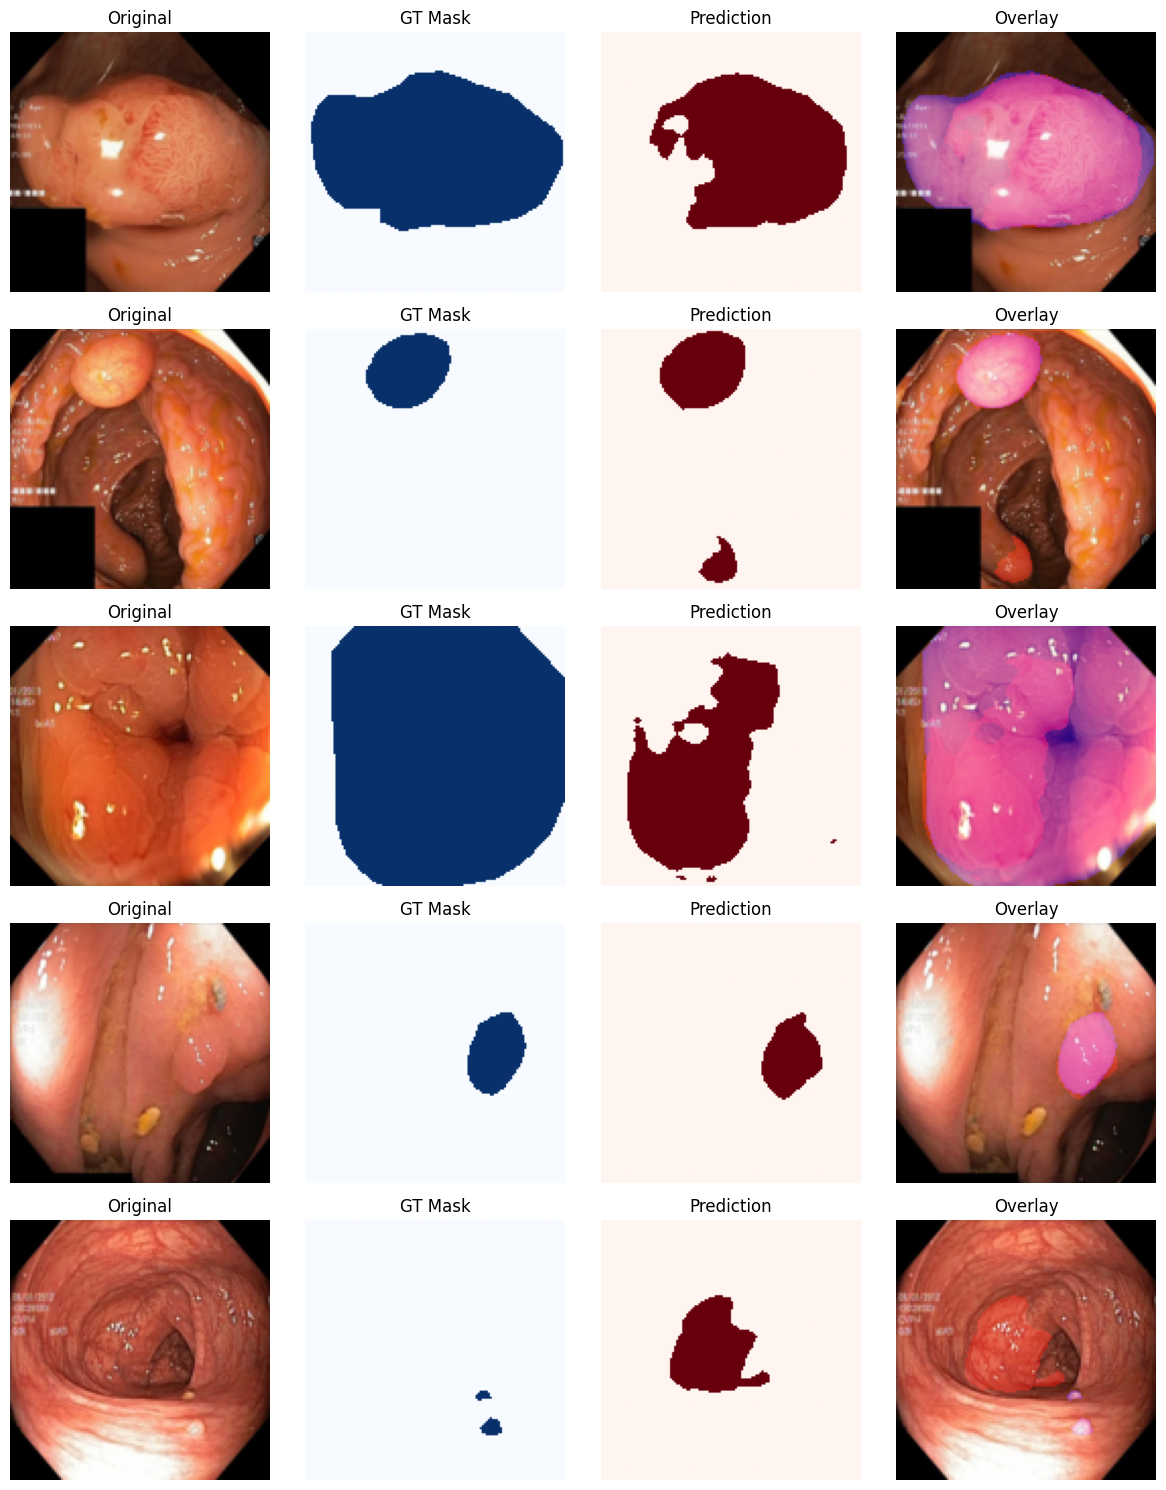

In [ ]:
best_model_path = ckpt.best_model_path
trained_model = LitUnet.load_from_checkpoint(best_model_path)
trainer.test(trained_model, datamodule=dm)

trained_model.eval()
xb, yb = next(iter(dm.test_dataloader()))

with torch.no_grad():
    logits = trained_model(xb)
    preds = torch.sigmoid(logits) > 0.5

num_examples = min(5, xb.size(0))

plt.figure(figsize=(12, 3*num_examples))

for i in range(num_examples):
    img = ((xb[i].permute(1,2,0).cpu().numpy() * 0.5) + 0.5).clip(0,1)
    
    gt_mask = yb[i,0].cpu().numpy()   
    pred_mask = preds[i,0].cpu().numpy()  
    
    overlay = img.copy()
    
    overlay[..., 2] = np.where(gt_mask>0, 1.0, overlay[...,2])
    
    overlay[..., 0] = np.where(pred_mask>0, 1.0, overlay[...,0])
    
    alpha = 0.5
    blended = (1-alpha)*img + alpha*overlay

    plt.subplot(num_examples, 4, 4*i+1)
    plt.imshow(img)
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+2)
    plt.imshow(gt_mask, cmap='Blues')
    plt.title('GT Mask')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+3)
    plt.imshow(pred_mask, cmap='Reds')
    plt.title('Prediction')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+4)
    plt.imshow(blended)
    plt.title('Overlay')
    plt.axis('off')

plt.tight_layout()
plt.show()


## Zadanie 4 – Transfer Learning: U-Net z pre-trained ResNet Encoder

Znowu wykorzystamy transfer learning do zbudowania sieci o większej skuteczności. Zamiast używać całej nauczonej wcześniej sieci wyciągniemy tylko kilka warstw i użyjemy ich w enkoderze modelu U-Net.

1. **ResNetEncoder:**
   - Zaimplementuj klasę `ResNetEncoder`, która dziedziczy po `nn.Module`.
   - W `__init__` przyjmij: `pretrained=True` (czy ładować pretrenowane wagi), `freeze_encoder=False` (czy wczytane wagi mają być zamrożone).
   - Wczytaj pretrained ResNet18: `models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)`.
   - Wyciągnij warstwy enkodera:
     - `resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool` – początkowe warstwy.
     - `resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4` – bloki ResNet (64, 128, 256, 512 kanałów).
   - Jeśli `freeze_encoder=True`, ustaw wszystkie parametry na `requires_grad=False` wewnątrz bloku `for param in self.parameters():`
   - W metodzie `forward(x)` przepuść dane przez warstwy i zwróć 5 tensorów skip connections: `x1` (po conv1), `x2` (po layer1), `x3` (po layer2), `x4` (po layer3), `x5` (po layer4/bottleneck).

2. **UNetResNet:**
   - Zaimplementuj klasę `UNetResNet`, która dziedziczy po `nn.Module`.
   - W `__init__` przyjmij: `pretrained=True`, `freeze_encoder=False`, `dropout`.
   - Stwórz encoder: `self.encoder = ResNetEncoder(pretrained, freeze_encoder)`.
   - Zbuduj decoder (podobnie jak w poprzednim zadaniu):
     - `ConvTranspose2d` upsampling z bottleneck (u1).
     - `DoubleConv` pamiętaj o konkatenacji wyjścia z u1 i skip connection z x4.
     - `ConvTranspose2d` (u2).
     - `DoubleConv` u2 + x3.
     - `ConvTranspose2d` (u3).
     - `DoubleConv` u3 + x2.
     - `ConvTranspose2d` (u4).
     - `DoubleConv` u4 + x1.
     - `ConvTranspose2d` powrót do orygionalej rozdzielczości.
     - `DoubleConv`.
   - Warstwa wyjściowa `Conv2d` z jednym kanałem wyjściowym o rozmiarze 1x1.
   - W metodzie `forward(x)`:
     - Wywołaj encoder: `x1, x2, x3, x4, x5 = self.encoder(x)`.
     - Przepuść przez decoder i skip connections.
     - Zwróć logity.

3. **LitUNetResNet:**
   - Zaimplementuj Lightning wrapper analogicznie do `LitUNet`.
   - Dodaj metody pomocnicze:
     - `freeze_encoder()`: zamraża wagi enkodera (tylko decoder będzie trenowany).
     - `unfreeze_encoder()`: odmraża encoder (cała sieć będzie trenowana).

4. **Test architektury:**
   - Stwórz instancję `UNetResNet`.
   - Przepuść losowy tensor przez sieć i sprawdź kształt wyjścia.
   - Wyświetl osobno liczbę wszystkich oraz liczbę uczonych parametrów `sum(p.numel() for p in model_tl.parameters() if p.requires_grad)`

In [8]:
class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True, freeze_encoder=False):
        super().__init__()

        if pretrained:
            resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        else:
            resnet = models.resnet18(weights=None)

        self.initial = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        if freeze_encoder:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, x):
        x1 = self.initial(x)
        x2 = self.layer1(x1)
        x3 = self.layer2(x2)
        x4 = self.layer3(x3)
        x5 = self.layer4(x4)
        return x1, x2, x3, x4, x5


class Decoder(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv2d(512 + 512, 512, dropout)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv2d(256 + 256, 256, dropout)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv2d(128 + 128, 128, dropout)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv2d(64 + 64, 64, dropout)

        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, x1, x2, x3, x4, x5):
        # Up 4
        x = self.upconv4(x)
        x = F.interpolate(x, size=x5.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x5], dim=1)
        x = self.dec4(x)

        # Up 3
        x = self.upconv3(x)
        x = F.interpolate(x, size=x4.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x4], dim=1)
        x = self.dec3(x)

        # Up 2
        x = self.upconv2(x)
        x = F.interpolate(x, size=x3.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x3], dim=1)
        x = self.dec2(x)

        # Up 1
        x = self.upconv1(x)
        x = F.interpolate(x, size=x2.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, x2], dim=1)
        x = self.dec1(x)

        return self.out_conv(x)

class UNetResNet(nn.Module):
    def __init__(self, pretrained=True, freeze_encoder=False, dropout=0.0):
        super().__init__()

        self.resnetEncoder = ResNetEncoder(pretrained, freeze_encoder)
        self.bottleneck = DoubleConv2d(512, 1024, dropout)
        self.decoder = Decoder(dropout)

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.resnetEncoder(x)
        x = self.bottleneck(x5)
        x = self.decoder(x, x1, x2, x3, x4, x5)

        return x

In [13]:
class LitUNetResNet(pl.LightningModule):
    def __init__(self, pretrained=True, freeze_encoder=True, dropout=0.0, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = UNetResNet(pretrained=pretrained, freeze_encoder=freeze_encoder, dropout=dropout)
        self.lr = lr  

        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss()

        self.iou = BinaryJaccardIndex()
        self.f1 = BinaryF1Score()

    def forward(self, x):
        return self.model(x)
    

    def freeze_encoder(self):
        for param in self.model.resnetEncoder.parameters():
            param.requires_grad = False

    def unfreeze_encoder(self):
        for param in self.model.resnetEncoder.parameters():
            param.requires_grad = True
    
    def compute_loss_and_metrics(self, batch):
        x, y = batch
        logits = self(x)
        
        # przeskalowanie maski do wymiarów wyjścia modelu
        y_resized = F.interpolate(y, size=logits.shape[2:], mode='nearest')
        
        loss = self.bce_loss(logits, y_resized) + self.dice_loss(logits, y_resized)
        
        with torch.inference_mode():
            pred_mask = (torch.sigmoid(logits) > 0.5).int()
            iou_score = self.iou(pred_mask, y_resized)
            f1_score = self.f1(pred_mask, y_resized)
        
        return loss, iou_score, f1_score

    def training_step(self, batch, batch_idx):
        loss, iou_score, f1_score = self.compute_loss_and_metrics(batch)

        self.log('train_loss_epoch', loss, on_epoch=True, prog_bar=True)
        self.log('train_iou_epoch', iou_score, on_epoch=True, prog_bar=True)
        self.log('train_dice_epoch', f1_score, on_epoch=True, prog_bar=True)
        
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss, iou_score, f1_score = self.compute_loss_and_metrics(batch)

        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_iou', iou_score, on_epoch=True, prog_bar=True)
        self.log('val_dice', f1_score, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, iou_score, f1_score = self.compute_loss_and_metrics(batch)

        self.log('test_loss', loss, on_epoch=True, prog_bar=True)
        self.log('test_iou', iou_score, on_epoch=True, prog_bar=True)
        self.log('test_dice', f1_score, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

In [14]:
# Test kształtu wyjścia i parametrów
model_tl = LitUNetResNet(dropout=0.0)
x = torch.randn(2, 3, 256, 256)  # batch 2, 3 kanały, 256x256
y_hat = model_tl(x)
print("Output shape:", y_hat.shape)

total_params = sum(p.numel() for p in model_tl.parameters())
trainable_params = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print("Total params:", total_params)
print("Trainable params:", trainable_params)


Output shape: torch.Size([2, 1, 64, 64])
Total params: 37530817
Trainable params: 26354305


## Zadanie 5 – Dwuetapowy Transfer Learning: Frozen Encoder

Trening chcemy wykonać podobnie jak w poprzednim ćwiczeniu, czyli zaczynamy od zamrożonych wag z transfer learningu, a potem wykonujemy fine-tuning. Proces treningu jest taki sam jak dla naszej wcześniejszej sieci.

**Trening z zamrożonym encoderem:**
1. Stwórz obiekt klasy `LitUNetResNet` z pretrenowanymi i zamrożonymi wagami.
2. Stwórz callbacki: `MetricsCallback`, `EarlyStopping`, `ModelCheckpoint`.
3. Stwórz `Trainer`.
4. Wywołaj trening sieci wywołując metodę `fit`
5. Wyświetl najlepszy checkpoint i val_dice.
6. Sprawdź oraz wyświetl metryki (3 wykresy: loss, dice, iou) podobnie jak we wcześniejszym treningu.
7. Wczytaj najlepszy model sieci i wykonaj dla niego testy na zbiorze testowym.
8. Wyświetl przykładowe predykcje (4 obrazy × 4 kolumny).

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="To copy construct from a tensor",
    category=UserWarning
)

model = LitUNetResNet(dropout=0.0)

metrics_callback = MetricsCallback()

early = EarlyStopping(
    monitor='val_dice',
    mode="max",
    patience=5, 
    verbose=True
)

ckpt = ModelCheckpoint(
    monitor='val_dice',
    mode='max',
    filename='sem2/PIAOM/lab5/data/best-unet-{epoch:02d}-{val_dice:.4f}',
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='auto',
    devices=1,
    callbacks=[metrics_callback, early, ckpt],
    precision=16  
)

trainer.fit(model, datamodule=dm)

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | UNetResNet         | 37.5 M | train
1 | bce_loss  | BCEWithLogitsLoss  | 0      | train
2 | dice_loss | DiceLoss           | 0      | train
3 | iou       | BinaryJaccardIndex | 0      | t

gut gut


/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (44) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|█| 44/44 [00:02<00:00, 17.74it/s, v_num=24, train_loss_epoch_step=0.393, train_iou_epoch_step=0.656, train_dice_epoch_step=0.792, val_loss=0.415, val_iou=0.645, val_dice=0.782, train_loss_epoch_

Metric val_dice improved. New best score: 0.782


...

Epoch 10: 100%|█| 44/44 [00:02<00:00, 15.46it/s, v_num=24, train_loss_epoch_step=0.158, train_iou_epoch_step=0.875, train_dice_epoch_step=0.933, val_loss=0.308, val_iou=0.755, val_dice=0.858, train_loss_epoch

Metric val_dice improved by 0.000 >= min_delta = 0.0. New best score: 0.858


Epoch 15: 100%|█| 44/44 [00:02<00:00, 15.63it/s, v_num=24, train_loss_epoch_step=0.319, train_iou_epoch_step=0.759, train_dice_epoch_step=0.863, val_loss=0.313, val_iou=0.754, val_dice=0.858, train_loss_epoch

Monitored metric val_dice did not improve in the last 5 records. Best score: 0.858. Signaling Trainer to stop.


Epoch 15: 100%|█| 44/44 [00:02<00:00, 15.61it/s, v_num=24, train_loss_epoch_step=0.319, train_iou_epoch_step=0.759, train_dice_epoch_step=0.863, val_loss=0.313, val_iou=0.754, val_dice=0.858, train_loss_epoch


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


gut gut
Testing DataLoader 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 39.19it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_dice           0.8876764178276062
        test_iou            0.7996719479560852
        test_loss           0.23324790596961975
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


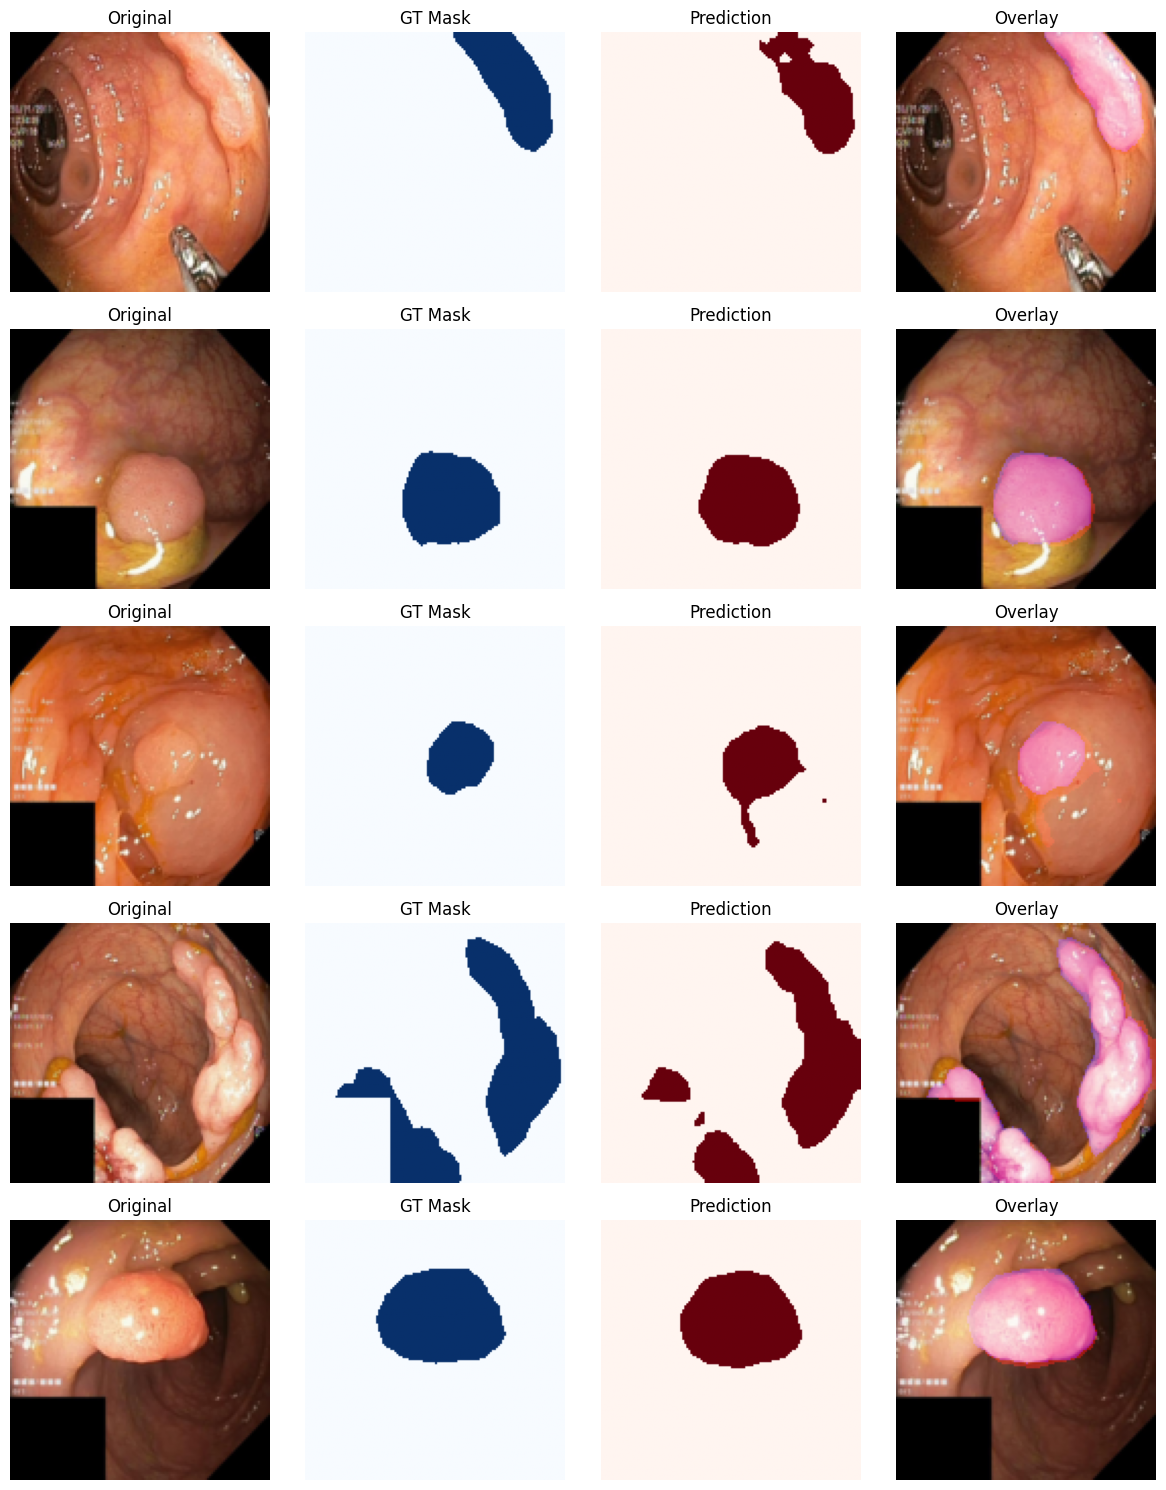

In [20]:
best_model_path = ckpt.best_model_path
trained_model = LitUNetResNet.load_from_checkpoint(best_model_path)
trainer.test(trained_model, datamodule=dm)

trained_model.eval()
xb, yb = next(iter(dm.test_dataloader()))

with torch.no_grad():
    logits = trained_model(xb)
    logits_resized = F.interpolate(logits, size=yb.shape[2:], mode='bilinear', align_corners=False)
    preds = torch.sigmoid(logits_resized) > 0.5

num_examples = min(5, xb.size(0))

plt.figure(figsize=(12, 3*num_examples))

for i in range(num_examples):
    img = ((xb[i].permute(1,2,0).cpu().numpy() * 0.5) + 0.5).clip(0,1)
    
    gt_mask = yb[i,0].cpu().numpy()
    pred_mask = preds[i,0].cpu().numpy()
    
    overlay = img.copy()
    overlay[..., 2] = np.where(gt_mask>0, 1.0, overlay[...,2])
    overlay[..., 0] = np.where(pred_mask>0, 1.0, overlay[...,0])
    
    alpha = 0.5
    blended = (1-alpha)*img + alpha*overlay

    plt.subplot(num_examples, 4, 4*i+1)
    plt.imshow(img)
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+2)
    plt.imshow(gt_mask, cmap='Blues')
    plt.title('GT Mask')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+3)
    plt.imshow(pred_mask, cmap='Reds')
    plt.title('Prediction')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+4)
    plt.imshow(blended)
    plt.title('Overlay')
    plt.axis('off')

plt.tight_layout()
plt.show()


## Zadanie 6 – Dwuetapowy Transfer Learning: Fine-tuning

**Fine-tuning całej sieci:**
1. Odmroź encoder dla najlepszego modelu z poporzedniej części.
2. Ustaw learning rate: `best_stage1.hparams.lr = ` (podczas fine-tuningu zazwyczaj jest mniejszy).
3. Zaktualizuj hparam: `best_stage1.hparams.freeze_encoder = False`.
4. Stwórz nowe callbacki: `MetricsCallback`, `EarlyStopping`, `ModelCheckpoint`.
5. Stwórz nowy `Trainer`.
6. Wykonaj trening wywołując metodę `fit`.
7. Sprawdź oraz wyświetl metryki (3 wykresy: loss, dice, iou) podobnie jak we wcześniejszym treningu.
8. Wczytaj najlepszy model sieci i wykonaj dla niego testy na zbiorze testowym.
9. Wyświetl przykładowe predykcje (4 obrazy × 4 kolumny).

In [22]:
model = LitUNetResNet(dropout=0.0)
model.unfreeze()

metrics_callback = MetricsCallback()

early = EarlyStopping(
    monitor='val_dice',
    mode="max",
    patience=5, 
    verbose=True
)

ckpt = ModelCheckpoint(
    monitor='val_dice',
    mode='max',
    filename='sem2/PIAOM/lab5/data/best-unet-{epoch:02d}-{val_dice:.4f}',
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='auto',
    devices=1,
    callbacks=[metrics_callback, early, ckpt],
    precision=16  
)

trainer.fit(model, datamodule=dm)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | UNetResNet         | 37.5 M | train
1 | bce_loss  | BCEWithLogitsLoss  | 0      | train
2 | dice_loss | DiceLoss           | 0      | train
3 | iou       | BinaryJaccardIndex | 0      | train
4 | f1        | BinaryF1Score      | 0      | train
---------------------------------------------------------
37.5 M    Trainable params
0         Non-trainable params
37.5 M    Total params
150.123   Total estimated model params size (MB)
128       Modules in train mode
0         Modules in eval mode


gut gut
Epoch 0: 100%|█| 44/44 [00:03<00:00, 13.30it/s, v_num=26, train_loss_epoch_step=0.524, train_iou_epoch_step=0.591, train_dice_epoch_step=0.743, val_loss=0.345, val_iou=0.730, val_dice=0.840, train_loss_epoch_

Metric val_dice improved. New best score: 0.840


Epoch 2: 100%|█| 44/44 [00:03<00:00, 13.62it/s, v_num=26, train_loss_epoch_step=0.496, train_iou_epoch_step=0.550, train_dice_epoch_step=0.710, val_loss=0.306, val_iou=0.768, val_dice=0.867, train_loss_epoch_

Metric val_dice improved by 0.027 >= min_delta = 0.0. New best score: 0.867


...

Metric val_dice improved by 0.004 >= min_delta = 0.0. New best score: 0.898


Epoch 10:  32%|▎| 14/44 [00:01<00:02, 11.53it/s, v_num=26, train_loss_epoch_step=0.279, train_iou_epoch_step=0.747, train_dice_epoch_step=0.855, val_loss=0.230, val_iou=0.818, val_dice=0.898, train_loss_epoch

terminate called after throwing an instance of 'c10::Error'
  what():  CUDA error: initialization error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

Exception raised from c10_cuda_check_implementation at /pytorch/c10/cuda/CUDAException.cpp:43 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x98 (0x7a425d7785e8 in /home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > const&) + 0xe0 (0x7a425d70d4a2 in /home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/torch/lib/libc10.so)
frame #2: c10::cu

SystemExit: 1

/home/patryk/Desktop/venv/ML_venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


gut gut
Testing DataLoader 0: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 38.81it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_dice           0.9097065329551697
        test_iou            0.8355986475944519
        test_loss           0.20619522035121918
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


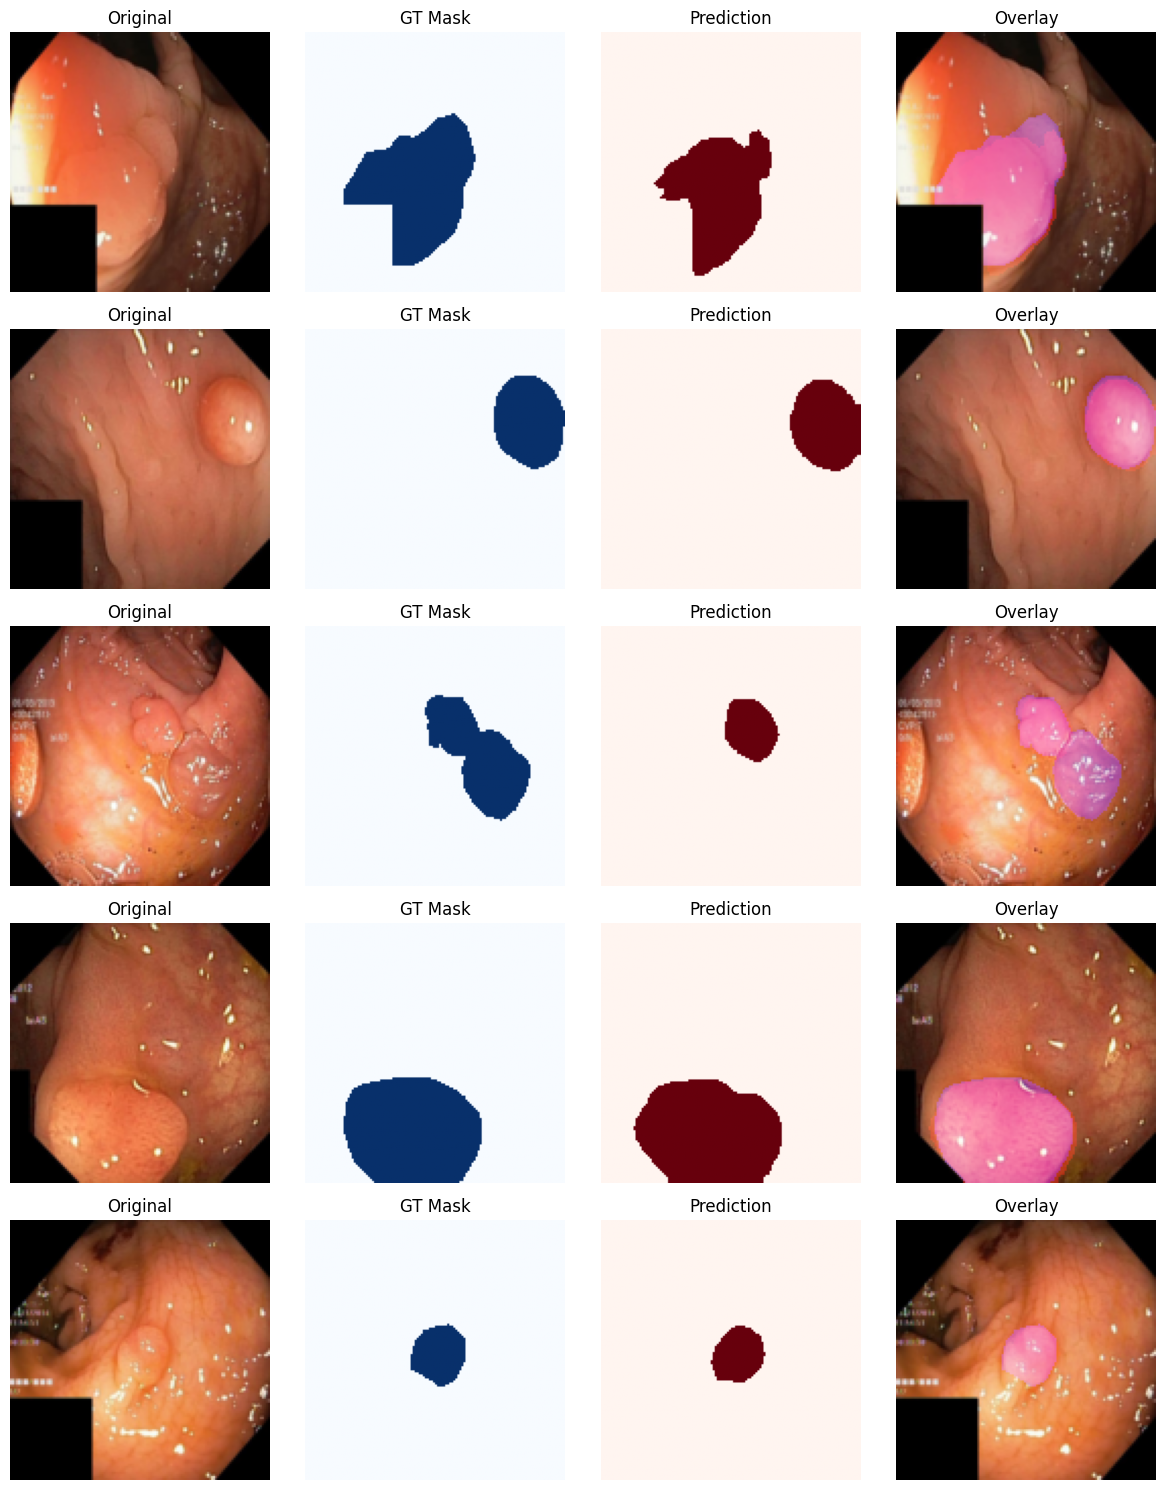

In [23]:
best_model_path = ckpt.best_model_path
trained_model = LitUNetResNet.load_from_checkpoint(best_model_path)
trainer.test(trained_model, datamodule=dm)

trained_model.eval()
xb, yb = next(iter(dm.test_dataloader()))

with torch.no_grad():
    logits = trained_model(xb)
    logits_resized = F.interpolate(logits, size=yb.shape[2:], mode='bilinear', align_corners=False)
    preds = torch.sigmoid(logits_resized) > 0.5

num_examples = min(5, xb.size(0))

plt.figure(figsize=(12, 3*num_examples))

for i in range(num_examples):
    img = ((xb[i].permute(1,2,0).cpu().numpy() * 0.5) + 0.5).clip(0,1)
    
    gt_mask = yb[i,0].cpu().numpy()
    pred_mask = preds[i,0].cpu().numpy()
    
    overlay = img.copy()
    overlay[..., 2] = np.where(gt_mask>0, 1.0, overlay[...,2])
    overlay[..., 0] = np.where(pred_mask>0, 1.0, overlay[...,0])
    
    alpha = 0.5
    blended = (1-alpha)*img + alpha*overlay

    plt.subplot(num_examples, 4, 4*i+1)
    plt.imshow(img)
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+2)
    plt.imshow(gt_mask, cmap='Blues')
    plt.title('GT Mask')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+3)
    plt.imshow(pred_mask, cmap='Reds')
    plt.title('Prediction')
    plt.axis('off')
    
    plt.subplot(num_examples, 4, 4*i+4)
    plt.imshow(blended)
    plt.title('Overlay')
    plt.axis('off')

plt.tight_layout()
plt.show()


---

## Podsumowanie i wnioski

Porównaj wyniki przeprowadzonych treningów sieci. Weź pod uwagę liczbę trenowanych parametrów.
Odpowiedz również krótko na poniższe pytania. 

1. Czym segmentacja różni się od zadania klasyfikacji?

2. Czym jest architektura U-Net? Czym ona się charakteryzuje?

3. Czym jest funkcja straty DiceLoss?